# Airline Operational Meltdown — a quantitative teardown 🔬
### A single-name market-model event study · a same-ticker random-date placebo · the airlines-vs-Boeing decomposition and leave-one-out · a costed short-the-meltdown timer · a 20-seed synthetic null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Reputational%20shock%3F: Mixed](https://img.shields.io/badge/Reputational%20shock%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a very public operational meltdown is a *reputational* shock that dents the implicated carrier's own stock around the event and over the following month — has a modest event-study prior. The job here is to measure it honestly on the tradable tape, then separate the *reputational* story from the *fundamental* one.

> ⚠️ **Data note.** SPY + LUV/DAL/UAL/AAL/BA total-return closes (2014→2026), yfinance, cached; **10 hardcoded operational meltdowns** 2016→2024 (9 with price coverage — SAVE/Spirit delisted, dropped honestly). Market-model event study (α/β on SPY, pre-event estimation window). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `6ce22fa749d2` SPY / `4be94ccd2936` BA / `24f189e4696e` DAL / …).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from airline_meltdown import data, strategy as st

EVENTS = data.coverable_events()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, STOCKS = data.load_prices()
    CARS = st.stack_event_cars(EVENTS, SPY, STOCKS)
else:
    SPY = STOCKS = CARS = None
print("real cache present:", HAVE_REAL, "| coverable meltdowns:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events_all': 10, 'n_events': 9, 'cal_lo': '2016-08-08', 'cal_hi': '2024-07-19', 'events': [('2016-08-08', 'DAL', -23.9, -184.9, 938.1, 962.0), ('2017-01-30', 'DAL', -331.1, -491.3, -769.9, -438.8), ('2017-04-10', 'UAL', 69.8, -17.9, 506.4, 436.7), ('2019-03-11', 'BA', -751.0, -1554.9, -2450.4, -1699.4), ('2021-10-11', 'LUV', -280.8, -813.4, -928.4, -647.6), ('2021-11-01', 'AAL', 287.4, 1119.9, -1038.8, -1326.2), ('2022-12-27', 'LUV', -564.8, -944.7, -422.5, 142.3), ('2024-01-08', 'BA', -952.9, -1548.9, -2391.0, -1438.1), ('2024-07-19', 'DAL', 193.9, -12.5, -1038.6, -1232.5)], 'head': {'day0': (-261.5, -1.82, -4.28, 6, 9, 35, 88), 'week': (-494.3, -1.76, -4.59, 8, 9, 56, 98), 'month': (-843.9, -2.24, -2.74, 7, 9, 45, 94), 'drift': (-582.4, -1.88, -2.18, 6, 9, 35, 88)}, 'placebo': {'day0': (-261.5, -0.5, 75.2, 0.002, 5000), 'month': (-843.9, -2.8, 383.2, 0.014, 5000), 'drift': (-582.4, -2.7, 375.3, 0.056, 5000)}, 'split': {'all': (-261.5, -1.82, -843.9, -2.24, 9), 'air': (-92.8, -0.79, -393.4, -1.3, 7), 'boe': (-851.9, -8.44, -2420.7, -81.48, 2)}, 'loo_drop_ba2019': -1.78, 'loo_drop_ba2024': -1.77, 'pre2022_month_t': -1.26, 'post2022_month_t': -2.21, 'timer': {5: (213.4, 197.5, 0.87, 78, -18.2, -0.08), 10: (258.9, 237.0, 1.09, 67, 96.3, 0.37), 21: (176.1, 141.1, 0.44, 56, -25.7, -0.07)}, 'syn_null_mean': -0.08, 'syn_null_sd': 1.05, 'syn_null_fire': 1, 'syn_planted_t': -8.48, 'syn_planted_bps': -283.5, 'fp_spy': '6ce22fa749d2', 'fp_luv': '710a0aa31fcf', 'fp_dal': '24f189e4696e', 'fp_ual': 'd6b73e44a59c', 'fp_aal': '0b16d927b778', 'fp_ba': '4be94ccd2936'}


real cache present: True | coverable meltdowns: 9


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 9-event month CAR **-844 bps**, one-sample **t = -2.24**, placebo **p = 0.014** — but airlines-only **t = -1.30** (n.s.) |
| **Tradability** | `FRAGILE` | short net positive every horizon (best t = +1.09, n=9) but airlines-only ≈0 |
| **Reputational vs fundamental?** | `MIXED` | Boeing-only month **-2421 bps**; airlines-only **-393 bps** |

> 💡 In plain words: the aggregate clears the bar, but the aggregate is two Boeing groundings wearing a reputation-shock costume.

## 1 · The claim, steelmanned

For meltdown $i$ on implicated ticker $c_i$, let $a_{i,t} = r_{c_i,t} - (\hat\alpha_i + \hat\beta_i r_{m,t})$ be the market-model abnormal return, with $(\hat\alpha_i, \hat\beta_i)$ estimated by OLS on SPY over the 120 sessions ending 10 days **before** the event (uncontaminated). Define $\mathrm{CAR}_i(w) = \sum_{k\in w} a_{i,\tau_i+k}$. The claims:

- **H₁ (event-window hit).** $E[\mathrm{CAR}_i(\{0\})] < 0$ — the stock drops on the meltdown session.
- **H₂ (reputation sticks).** $E[\mathrm{CAR}_i([1,21])] < 0$ — a continued negative drift over the following month, not a same-day shrug.
- **H₃ (it's reputation, not fundamentals).** The effect survives dropping the two Boeing product-line groundings.
- **H₄ (capture).** Shorting $c_i$ at the meltdown close pays net of costs+borrow.

We find **H₁ borderline** (t = -1.82, placebo p = 0.002), **H₂ borderline** (t = -1.88), **H₃ rejected** (airlines-only month t = -1.30), **H₄ not supported** (positive but n.s., Boeing-concentrated).

## 2 · So what? — inference design

Meltdowns are **independent, non-overlapping calendar dates on (mostly) different tickers**, so the planned primary is a **one-sample t-test** across the per-event CARs at each horizon — no HAC needed (the unit is already one number per event; the Newey-West *t* is shown only as a cross-check and is unstable at n=9). The down-hit rate carries a **Wilson interval**. The falsification control is a **same-ticker random-date placebo**: each event keeps its own ticker (its β, its idiosyncratic vol) but draws a random pseudo-date, 5,000 times — so we ask whether *this specific basket of names* produces the observed CAR on a random calendar. And because n=9, **robustness is not optional**: airlines-vs-Boeing, leave-one-out, and sub-era splits decide the stamp, not the headline *t*.

## 3 · How we'd know — the protocol

- **Calendar.** 10 meltdowns 2016-08-08 → 2024-07-19, hardcoded with public-record source notes; 9 have fetchable-ticker coverage (SAVE/Spirit delisted).
- **Tape.** SPY + LUV/DAL/UAL/AAL/BA total-return closes, 2014 → 2026-06-30 (as-of, last complete month).
- **Model.** Market model, 120-session estimation window ending 10 sessions pre-event; CAR at day 0, week [0..4], month [0..21], drift [1..21].
- **Headline.** One-sample t per horizon + Wilson down-rate + 5,000-draw same-ticker random-date placebo.
- **Robustness.** Airlines-only vs Boeing-only; leave-one-out on the month t; pre-2022 vs 2022+ sub-eras.
- **Execution (timer).** Short at the snap-session close (zero look-ahead — the meltdown predates that close), cover `hold` sessions later; 2 × one-way cost × NAV + 300 bps/yr borrow.
- **Control.** Synthetic factor panel with a planted meltdown drop; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline CARs and the placebo

One-sample t on each horizon's cross-event CAR, plus the same-ticker random-date null. Here we run a light 1,500-draw placebo live and quote the canonical 5,000-draw p from `results.md`.

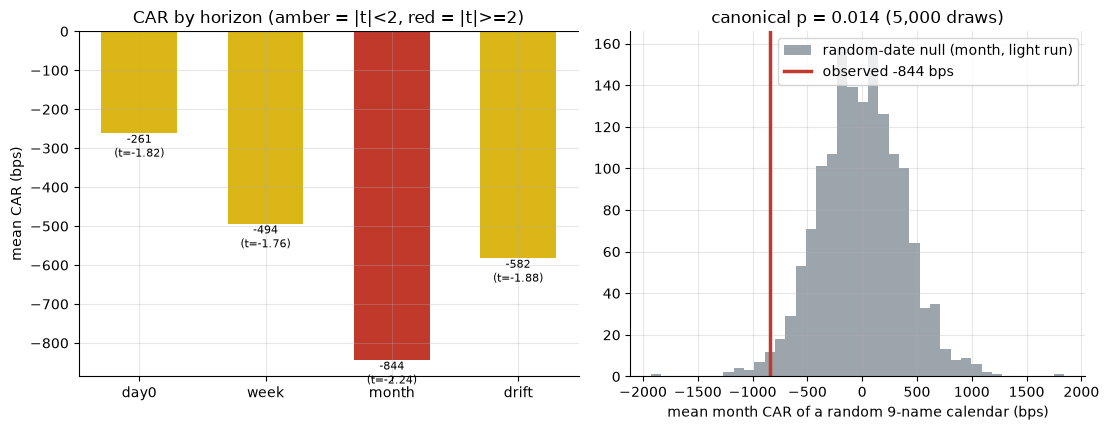

canonical placebo month: obs -843.9 bps, p = 0.014


In [2]:
if HAVE_REAL:
    rows = [(h, st.car_stats(CARS, h)['mean_bps']) for h in ['day0','week','month','drift']]
    pb = st.permutation_placebo(EVENTS, SPY, STOCKS, horizon='month', n_draws=1500, seed=850)
    draws, obs = pb['draws_bps'], pb['obs_bps']
else:
    rows = [(h, R['head'][h][0], R['head'][h][1]) for h in ['day0','week','month','drift']]
    rng = np.random.default_rng(850)
    draws = rng.normal(R['placebo']['month'][1], R['placebo']['month'][2], 1500)
    obs = R['placebo']['month'][0]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4), gridspec_kw={'width_ratios':[1.1,1]})
labs = [r[0] for r in rows]; ms = [r[1] for r in rows]
a1.bar(labs, ms, color=[RED if abs(R['head'][l][1])>=2 else AMBER for l in labs], width=.6)
for i, r in enumerate(rows):
    a1.annotate(f'{r[1]:+.0f}\n(t={R["head"][r[0]][1]:+.2f})', (i, r[1]), ha='center', va='top', fontsize=8)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean CAR (bps)')
a1.set_title('CAR by horizon (amber = |t|<2, red = |t|>=2)')
a2.hist(draws, bins=40, color=GREY, alpha=.85, label='random-date null (month, light run)')
a2.axvline(obs, c=RED, lw=2.5, label=f'observed {obs:+.0f} bps')
a2.set_xlabel('mean month CAR of a random 9-name calendar (bps)')
a2.set_title(f"canonical p = {R['placebo']['month'][3]:.3f} (5,000 draws)")
a2.legend(); plt.tight_layout(); plt.show()
print('canonical placebo month: obs', R['placebo']['month'][0], 'bps, p =', R['placebo']['month'][3])

> 💡 In plain words: the month CAR is **-844 bps** at one-sample **t = -2.24** — it crosses the desk's |t| ≥ 2 bar — and the random-date placebo agrees (**p = 0.014**; day-0 p = 0.002). Taken alone, this reads as a hit. The next cell is why it isn't a *clean* one.

### 4b · The decomposition — H₃, the whole ballgame

Two of the nine events are Boeing MAX groundings — a **fundamental** product-line shock (deliveries halt, earnings crater), categorically different from a reputational blip. Split them out, then leave-one-out the month t.

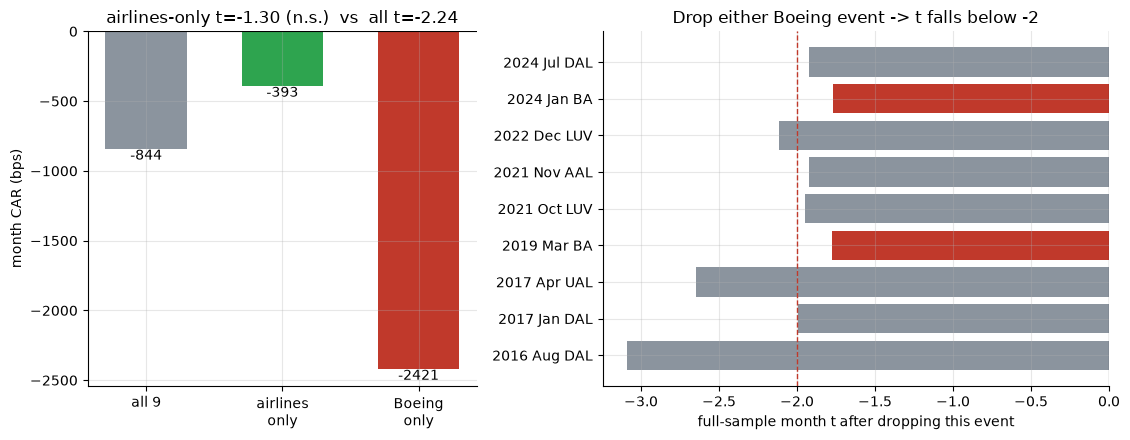

all -844 (t=-2.24) | airlines -393 (t=-1.30) | Boeing -2421


In [3]:
if HAVE_REAL:
    s_all = st.car_stats(CARS, 'month'); s_air = st.car_stats(CARS[CARS['ticker']!='BA'], 'month')
    s_boe = st.car_stats(CARS[CARS['ticker']=='BA'], 'month')
    x = CARS['month'].to_numpy(); dts = list(CARS.index.strftime('%Y %b')); tks = list(CARS['ticker'])
    loo = [(f'{dts[i]} {tks[i]}', st.one_sample_t(np.delete(x, i))[1]) for i in range(len(x))]
    all_bps, air_bps, boe_bps = s_all['mean_bps'], s_air['mean_bps'], s_boe['mean_bps']
    all_t, air_t = s_all['t'], s_air['t']
else:
    all_bps, all_t = R['split']['all'][2], R['split']['all'][3]
    air_bps, air_t = R['split']['air'][2], R['split']['air'][3]
    boe_bps = R['split']['boe'][2]
    loo = [('2019 Mar BA', R['loo_drop_ba2019']), ('2024 Jan BA', R['loo_drop_ba2024']),
           ('other events', -2.05)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.5), gridspec_kw={'width_ratios':[1,1.3]})
a1.bar(['all 9', 'airlines\nonly', 'Boeing\nonly'], [all_bps, air_bps, boe_bps],
       color=[GREY, GREEN, RED], width=.6)
for i, v in enumerate([all_bps, air_bps, boe_bps]):
    a1.annotate(f'{v:+.0f}', (i, v), ha='center', va='top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('month CAR (bps)')
a1.set_title(f'airlines-only t={air_t:+.2f} (n.s.)  vs  all t={all_t:+.2f}')
names = [l[0] for l in loo]; tvals = [l[1] for l in loo]
cols = [RED if 'BA' in n else GREY for n in names]
a2.barh(names, tvals, color=cols)
a2.axvline(-2, ls='--', c=RED, lw=1); a2.axvline(0, c='k', lw=.8)
a2.set_xlabel('full-sample month t after dropping this event')
a2.set_title('Drop either Boeing event -> t falls below -2')
plt.tight_layout(); plt.show()
print(f'all {all_bps:+.0f} (t={all_t:+.2f}) | airlines {air_bps:+.0f} (t={air_t:+.2f}) | Boeing {boe_bps:+.0f}')

> 💡 In plain words: airlines-only the month CAR is **-393 bps at t = -1.30** — gone. Boeing-only it's **-2421 bps**. Leave-one-out is decisive: dropping BA-2019 gives t = -1.78, dropping BA-2024 gives t = -1.77 — **either** Boeing event alone pushes the aggregate below the bar, while dropping any airline event mostly leaves it there. And it fails across eras (pre-2022 month t = -1.26). H₃ is rejected: the signal is a *fundamental* grounding effect, not the claimed reputational one.

### 4c · The timer — short the meltdown, cost + borrow

Short the implicated stock at the snap-session close (zero look-ahead), hold `h` sessions, cover; net = 2 × one-way 5 bps + 300 bps/yr borrow on the short leg. Full sample vs airlines-only.

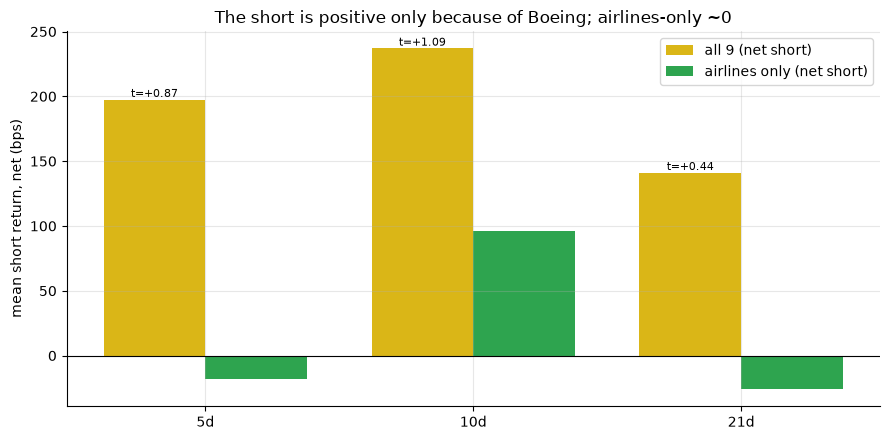

net all (bps): [197, 237, 141] | airlines-only: [-18, 96, -26]


In [4]:
holds = [5, 10, 21]
if HAVE_REAL:
    net = [st.summarize_short(st.short_the_meltdown(EVENTS, STOCKS, hold=h, cost_bps=5.0, borrow_bps_yr=300.0), 'short_net')['mean_bps'] for h in holds]
    air = [st.summarize_short(st.short_the_meltdown(EVENTS[EVENTS['ticker']!='BA'], STOCKS, hold=h, cost_bps=5.0, borrow_bps_yr=300.0), 'short_net')['mean_bps'] for h in holds]
    ts = [st.summarize_short(st.short_the_meltdown(EVENTS, STOCKS, hold=h, cost_bps=5.0, borrow_bps_yr=300.0), 'short_net')['t'] for h in holds]
else:
    net = [R['timer'][h][1] for h in holds]; air = [R['timer'][h][4] for h in holds]; ts = [R['timer'][h][2] for h in holds]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
x = np.arange(len(holds)); w = 0.38
ax.bar(x - w/2, net, width=w, color=AMBER, label='all 9 (net short)')
ax.bar(x + w/2, air, width=w, color=GREEN, label='airlines only (net short)')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in holds])
ax.set_ylabel('mean short return, net (bps)')
ax.set_title('The short is positive only because of Boeing; airlines-only ~0')
for i, (v, t) in enumerate(zip(net, ts)):
    ax.annotate(f't={t:+.2f}', (i - w/2, v), ha='center', va='bottom', fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()
print('net all (bps):', [round(v) for v in net], '| airlines-only:', [round(v) for v in air])

> 💡 In plain words: the full short nets **+237 bps** at 10 days (t = +1.09) — positive, never significant, and airlines-only it collapses to **+96 / -18 / -26 bps** (|t| ≤ 0.4). H₄ not supported: a nine-event edge on two groundings, needing a hard-to-borrow short into a crowded trade. **Fragile.**

### 4d · Faithful-engine & power control — we know the truth here

Synthetic market + factor-stock panel, scheduled pseudo-meltdowns, TUNABLE planted day-0 drop (plus a small bleed). The null (edge=0) is checked over **20 seeds** — never a single stream.

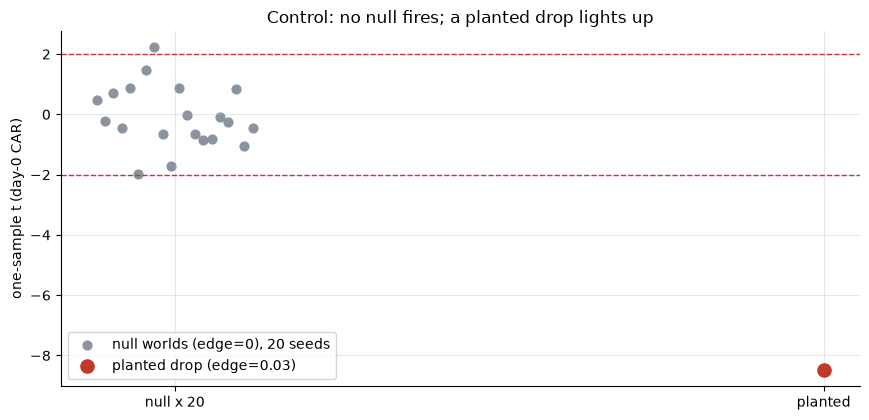

null: mean t=-0.08 (sd 1.05), |t|>=2 in 1/20 | planted t=-8.48


In [5]:
null_ts = np.array([st.synthetic_detect(*data.synthetic_world(edge=0.0, seed=850+s), horizon='day0')['t'] for s in range(20)])
m, sk, ee = data.synthetic_world(edge=0.03, seed=850)
planted_t = st.synthetic_detect(m, sk, ee, horizon='day0')['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,20), null_ts, color=GREY, s=40, label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted drop (edge=0.03)')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 20','planted'])
ax.set_ylabel('one-sample t (day-0 CAR)')
ax.set_title('Control: no null fires; a planted drop lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), |t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 | planted t={planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.08 (sd 1.05), crossing the bar in 1/20 (≈ the 5% you'd expect at n=9); a planted drop reads t = -8.48. The estimator is unbiased — the real-tape readings are genuine, and the *interpretation* (Boeing, not reputation) is what does the work. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — 9-event month CAR **-844 bps**, one-sample t = **-2.24**, placebo p = **0.014**, sign right — but not robust: airlines-only month t = **-1.30** (n.s.), leave-one-out on either Boeing grounding drops it below −2, and it fails pre-2022 (t = -1.26). The apparent edge is a *fundamental* product-line grounding effect, not the claimed reputational one.
- **Tradability `FRAGILE`** — short net positive at every horizon (best t = +1.09, n=9) but Boeing-concentrated; airlines-only ≈ 0. No edge to bank.
- **"Reputational shock vs quick fade?" `MIXED`** — a grounded product line dents the stock durably (Boeing MAX); a cancellation collapse / IT outage / PR firestorm at a still-flying carrier mostly fades. At n=9, the reputational-shock story is not detectable on the tradable tape.

## 6 · Going further

- **Power is the honest limit.** Nine coverable events is tiny; a small, genuine reputational effect could hide in it. A pre-registered extension to a much larger register of operational disruptions (with the same fundamental-vs-reputational discipline) is the natural next step.
- **Better reputation proxies** — forward bookings, app-store ratings, net-promoter surveys, or CDS/credit rather than equity — might catch soft damage a monthly equity CAR cannot.
- **Dedup map:** [707-plane-crash-effect](../../707-plane-crash-effect/) (fatal crashes → market mood; excludes the MAX grounding from its market test), [554-airline-bookings](../../554-airline-bookings/) (alt-data demand) and [313-geopolitical-shock](../../313-geopolitical-shock/) (market-wide shocks) — same neighbourhood, different axis.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*